In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.preprocessing import StandardScaler,OneHotEncoder

In [2]:
url="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/_0eYOqji3unP1tDNKWZMjg/weatherAUS-2.csv"
df = pd.read_csv(url)
df.head()
df.shape

(145460, 23)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [4]:
df.isna().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

In [5]:
df.dropna(inplace=True)

In [6]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
6049,2009-01-01,Cobar,17.9,35.2,0.0,12.0,12.3,SSW,48.0,ENE,...,20.0,13.0,1006.3,1004.4,2.0,5.0,26.6,33.4,No,No
6050,2009-01-02,Cobar,18.4,28.9,0.0,14.8,13.0,S,37.0,SSE,...,30.0,8.0,1012.9,1012.1,1.0,1.0,20.3,27.0,No,No
6052,2009-01-04,Cobar,19.4,37.6,0.0,10.8,10.6,NNE,46.0,NNE,...,42.0,22.0,1012.3,1009.2,1.0,6.0,28.7,34.9,No,No
6053,2009-01-05,Cobar,21.9,38.4,0.0,11.4,12.2,WNW,31.0,WNW,...,37.0,22.0,1012.7,1009.1,1.0,5.0,29.1,35.6,No,No
6054,2009-01-06,Cobar,24.2,41.0,0.0,11.2,8.4,WNW,35.0,NW,...,19.0,15.0,1010.7,1007.4,1.0,6.0,33.6,37.6,No,No


#### Better predictions are resulted when specific location data is trained as different area have different patterns of weather

Therefore, let us filter out the data and make some predictions

In [7]:
#Let us look at different locations available 
df['Location'].unique()
#Try to predict sydney weather
data = df[df['Location'].isin(['Sydney','SydneyAirport','Williamtown'])]

In [8]:
data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
31168,2010-10-20,Sydney,12.9,20.3,0.2,3.0,10.9,ENE,37.0,W,...,70.0,57.0,1028.8,1025.6,3.0,1.0,16.9,19.8,No,No
31169,2010-10-21,Sydney,13.3,21.5,0.0,6.6,11.0,ENE,41.0,W,...,75.0,58.0,1025.9,1022.4,2.0,5.0,17.6,21.3,No,No
31170,2010-10-22,Sydney,15.3,23.0,0.0,5.6,11.0,NNE,41.0,W,...,70.0,63.0,1021.4,1017.8,1.0,4.0,19.0,22.2,No,No
31174,2010-10-26,Sydney,12.9,26.7,0.2,3.8,12.1,NE,33.0,W,...,73.0,56.0,1018.0,1015.0,1.0,5.0,17.8,22.5,No,No
31175,2010-10-27,Sydney,14.8,23.8,0.0,6.8,9.6,SSE,54.0,SSE,...,76.0,69.0,1016.0,1014.7,2.0,7.0,20.2,20.6,No,Yes


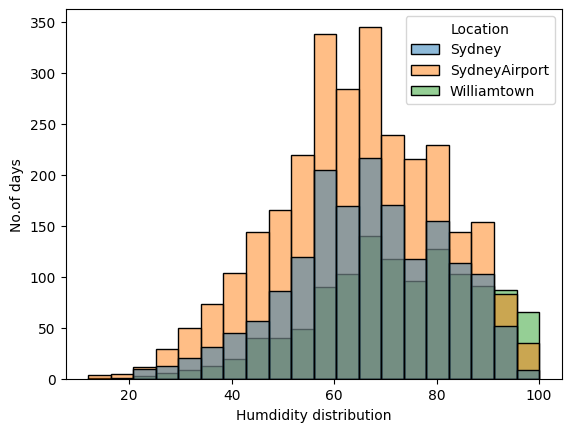

In [10]:
#Check how humidity plays a role on the area
sns.histplot(x='Humidity9am',data=data,bins=20,hue='Location')
plt.ylabel('No.of days')
plt.xlabel('Humdidity distribution')
plt.show()

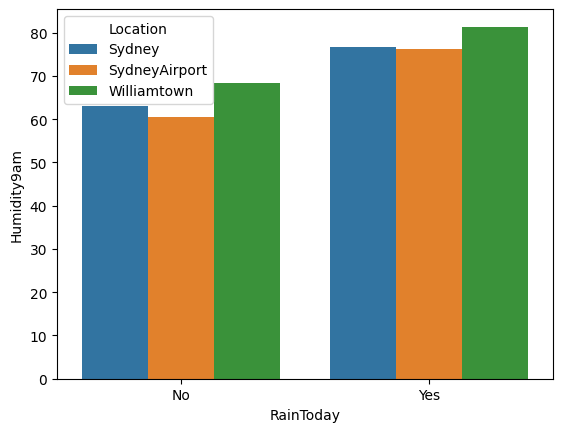

In [11]:
#Effect of humidity on Rainfall
req = data.groupby(['RainToday','Location'])['Humidity9am'].mean().reset_index()
req.head()
sns.barplot(x='RainToday',y='Humidity9am',hue='Location',data=req)
plt.show()

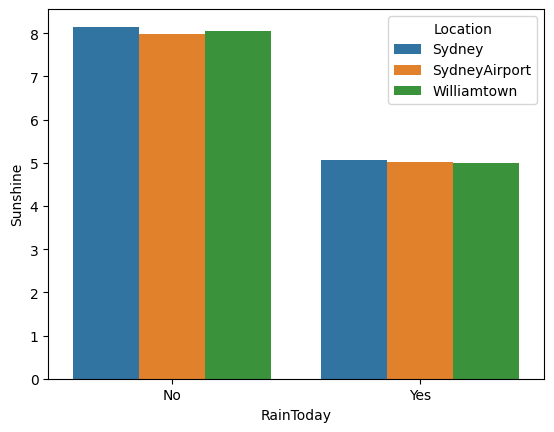

In [43]:
req2 = data.groupby(['RainToday','Location'])['Sunshine'].mean().reset_index()
req2.head()
sns.barplot(x='RainToday',y='Sunshine',hue='Location',data=req2)
plt.show()

All these plots tell us that when there's a rainfall, the sunshine is down,humidity is up but they dont generalize the rainfall prediction as the differences are not huge

#### Data preprocessing

Data preprocessing important beacuase the datasets are generally not consistent with continuous, categorical variables and all data do not have similar magnitude of data.Converting categorical to continuous helps dataset to be consistent and the models perform better with same data type across the data.Standardizing data is also important so that model does not show any bias towards large magnitude data

In [12]:
data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
31168,2010-10-20,Sydney,12.9,20.3,0.2,3.0,10.9,ENE,37.0,W,...,70.0,57.0,1028.8,1025.6,3.0,1.0,16.9,19.8,No,No
31169,2010-10-21,Sydney,13.3,21.5,0.0,6.6,11.0,ENE,41.0,W,...,75.0,58.0,1025.9,1022.4,2.0,5.0,17.6,21.3,No,No
31170,2010-10-22,Sydney,15.3,23.0,0.0,5.6,11.0,NNE,41.0,W,...,70.0,63.0,1021.4,1017.8,1.0,4.0,19.0,22.2,No,No
31174,2010-10-26,Sydney,12.9,26.7,0.2,3.8,12.1,NE,33.0,W,...,73.0,56.0,1018.0,1015.0,1.0,5.0,17.8,22.5,No,No
31175,2010-10-27,Sydney,14.8,23.8,0.0,6.8,9.6,SSE,54.0,SSE,...,76.0,69.0,1016.0,1014.7,2.0,7.0,20.2,20.6,No,Yes


#### Note that we need to initially separate X and Y data before using pipelines and column transformer to standradize and encode numeric and categorical data respectively

In [9]:
x = data.drop(columns=['Date','RainTomorrow'])
y=data['RainTomorrow']

In [10]:
#data.drop('Date',axis=1,inplace=True)
num_features = x.select_dtypes(include=['number']).columns.tolist()
cat_features = x.select_dtypes(include=['object','category']).columns.tolist()
print('Categorical features are OneHot encoded: ',cat_features)
print('Numerical features are standardized: ',num_features)

Categorical features are OneHot encoded:  ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
Numerical features are standardized:  ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


Checking the balance of target is important in classification

In [11]:
y.value_counts()

RainTomorrow
No     4307
Yes    1451
Name: count, dtype: int64

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,stratify=y)

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [25]:
num_features = x_train.select_dtypes(include=['number']).columns.tolist()
cat_features = x_train.select_dtypes(include=['object','category']).columns.tolist()
num_transformer = Pipeline(steps=[('scalar',StandardScaler())])
cat_transformer = Pipeline(steps=[('onehot',OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer(transformers=[('num',num_transformer,num_features),('cat',cat_transformer,cat_features)])

In [26]:
pipe = Pipeline(steps=[('preprocessor',preprocessor),('log',LogisticRegression(max_iter=500))])

              precision    recall  f1-score   support

          No       0.90      0.79      0.84       862
         Yes       0.55      0.74      0.63       290

    accuracy                           0.78      1152
   macro avg       0.72      0.77      0.74      1152
weighted avg       0.81      0.78      0.79      1152



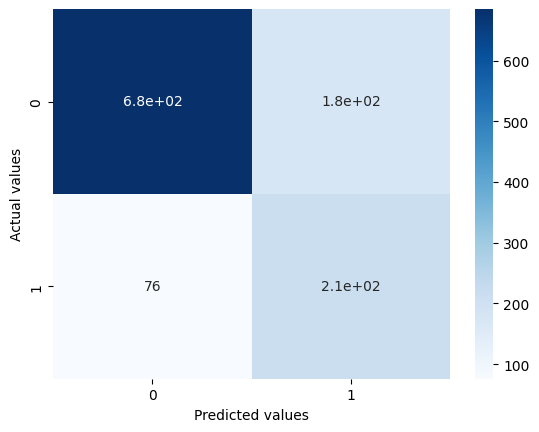

In [19]:
cv = StratifiedKFold(n_splits=5,shuffle=True)
params = {'log__C':[0.01,0.1,1],'log__penalty':['l1','l2'],'log__solver':['saga'],'log__class_weight':['balanced']}
grid = GridSearchCV(pipe,param_grid=params,cv=cv)
grid.fit(x_train,y_train)
y_pred = grid.predict(x_test)
print(classification_report(y_test,y_pred))
conf = confusion_matrix(y_test,y_pred)
sns.heatmap(conf,annot=True,cmap='Blues')
plt.ylabel('Actual values')
plt.xlabel('Predicted values')
plt.show()

Let us try using XGBoost algorithm for classifcation

In [32]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train)
y_test_xgb = le.fit_transform(y_test)

In [ ]:
from xgboost import XGBClassifier
pipe2 = Pipeline(steps=[('preprocessor',preprocessor),('xgboost',XGBClassifier())])
cv = StratifiedKFold(n_splits=5,shuffle=True)
params2 = {'xgboost__n_estimators':[100,150,200],'xgboost__max_depth':[4,6,8],'xgboost__learning_rate':[0.01,0.1,0.2],'xgboost__subsample':[0.5,0.7,1]}
grid_xg = GridSearchCV(pipe2,param_grid=params2,cv=cv)
grid_xg.fit(x_train,y_train_xgb)
print('Best parameters found are: ',grid_xg.best_params_)
y_pred2 = grid_xg.predict(x_test)

Best parameters found are:  {'xgboost__learning_rate': 0.1, 'xgboost__max_depth': 8, 'xgboost__n_estimators': 200, 'xgboost__subsample': 1}


array([0, 0, 1, ..., 0, 0, 0], shape=(1152,))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       862
           1       0.74      0.60      0.66       290

    accuracy                           0.85      1152
   macro avg       0.81      0.77      0.78      1152
weighted avg       0.84      0.85      0.84      1152



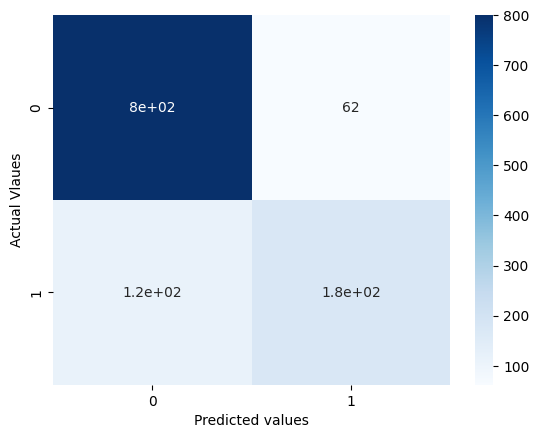

In [38]:
print(classification_report(y_test_xgb,y_pred2))
conf_xgb = confusion_matrix(y_test_xgb,y_pred2)
sns.heatmap(conf_xgb,annot=True,cmap='Blues')
plt.xlabel('Predicted values')
plt.ylabel('Actual Vlaues')
plt.show()


#### Preparing the dataset for visualizations

In [ ]:
rainfall_df = df.copy()
rainfall_df.sample(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
102767,2009-08-03,Nuriootpa,2.3,14.5,1.2,6.8,6.9,WSW,37.0,NE,...,11.0,87.0,58.0,1026.6,1023.0,6.0,6.0,7.2,14.0,Yes
103679,2012-03-02,Nuriootpa,12.9,22.3,0.0,5.8,7.4,SE,57.0,SE,...,19.0,77.0,56.0,1011.5,1008.9,7.0,5.0,13.8,20.8,No
80660,2016-07-23,Watsonia,6.6,11.1,2.2,3.4,5.9,W,57.0,W,...,20.0,65.0,66.0,1004.6,1008.7,3.0,7.0,7.9,9.0,Yes
138383,2015-06-29,AliceSprings,7.1,22.1,0.0,4.0,9.4,S,33.0,SE,...,20.0,66.0,41.0,1026.4,1022.6,2.0,2.0,13.5,21.3,No
100696,2012-03-28,MountGambier,8.6,26.3,0.0,3.4,9.6,W,30.0,NE,...,15.0,85.0,35.0,1020.4,1017.1,1.0,2.0,12.9,25.2,No


In [9]:
rainfall_df.drop('RainTomorrow',axis=1,inplace=True)

In [12]:
rainfall_df['Date'] = pd.to_datetime(rainfall_df['Date'])

In [15]:
rainfall_df.to_csv('rainfall_data.csv',index=False)

#### Trying something different

In [7]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
6049,2009-01-01,Cobar,17.9,35.2,0.0,12.0,12.3,SSW,48.0,ENE,...,20.0,13.0,1006.3,1004.4,2.0,5.0,26.6,33.4,No,No
6050,2009-01-02,Cobar,18.4,28.9,0.0,14.8,13.0,S,37.0,SSE,...,30.0,8.0,1012.9,1012.1,1.0,1.0,20.3,27.0,No,No
6052,2009-01-04,Cobar,19.4,37.6,0.0,10.8,10.6,NNE,46.0,NNE,...,42.0,22.0,1012.3,1009.2,1.0,6.0,28.7,34.9,No,No
6053,2009-01-05,Cobar,21.9,38.4,0.0,11.4,12.2,WNW,31.0,WNW,...,37.0,22.0,1012.7,1009.1,1.0,5.0,29.1,35.6,No,No
6054,2009-01-06,Cobar,24.2,41.0,0.0,11.2,8.4,WNW,35.0,NW,...,19.0,15.0,1010.7,1007.4,1.0,6.0,33.6,37.6,No,No


In [9]:
df['Location'].unique()
Perth_data = df[df['Location'].isin(['Perth','PerthAirport','Woomera','Cairns'])]
Perth_data.sample(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
89360,2015-01-28,Cairns,24.5,36.1,0.0,5.4,11.0,NE,30.0,SSW,...,50.0,68.0,1001.6,999.6,5.0,6.0,32.3,32.4,No,No
118478,2011-05-30,PerthAirport,15.3,21.9,18.8,4.6,6.7,NNE,43.0,N,...,91.0,62.0,1010.4,1010.3,4.0,5.0,17.3,21.5,Yes,Yes
121192,2010-01-06,Perth,22.1,33.0,0.0,13.6,12.7,ESE,37.0,NNE,...,45.0,62.0,1003.7,1005.6,5.0,7.0,27.6,27.3,No,No
88784,2013-07-01,Cairns,15.3,24.6,0.0,4.8,10.6,SSE,35.0,S,...,43.0,37.0,1018.1,1014.4,1.0,0.0,20.0,23.7,No,No
122762,2014-07-23,Perth,9.0,15.8,5.6,0.4,4.3,WNW,22.0,ENE,...,96.0,86.0,1022.8,1020.6,7.0,6.0,10.7,13.2,Yes,Yes


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
x = Perth_data.select_dtypes(include=['number'])
y = Perth_data['RainTomorrow']
dtc = DecisionTreeClassifier(class_weight='balanced')
x_train_dtc,x_test_dtc,y_train_dtc,y_test_dtc = train_test_split(x,y,test_size=0.2,stratify=y)
dtc.fit(x_train_dtc,y_train_dtc)
y_pred_dtc = dtc.predict(x_test_dtc)
print('Predictions are: ',y_pred_dtc)
print(classification_report(y_test_dtc,y_pred_dtc))


Predictions are:  ['No' 'Yes' 'No' ... 'Yes' 'No' 'No']
              precision    recall  f1-score   support

          No       0.90      0.90      0.90      1614
         Yes       0.60      0.60      0.60       410

    accuracy                           0.84      2024
   macro avg       0.75      0.75      0.75      2024
weighted avg       0.84      0.84      0.84      2024

Accuracy of the model:  0.8364624505928854


We can understand from the classification report that this model is not optimal predictor.It needs improvements.The data is not consistent that means different variables have different magnitude of data also we removed categorical variables for the model and may miss out some important features.Therfore, we need to encode those and scale the numeric features to improve consistency in the data.

              precision    recall  f1-score   support

          No       0.94      0.85      0.89      1614
         Yes       0.56      0.78      0.65       410

    accuracy                           0.83      2024
   macro avg       0.75      0.81      0.77      2024
weighted avg       0.86      0.83      0.84      2024



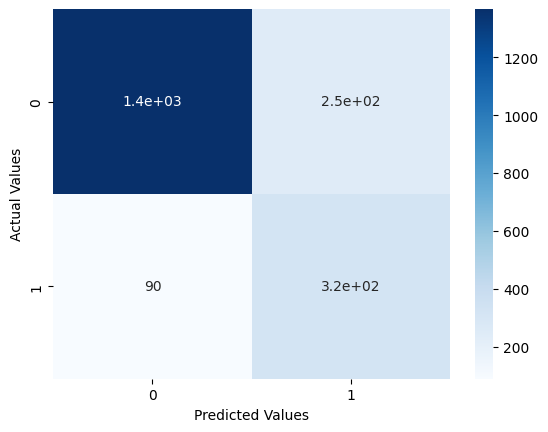

In [20]:
#Lets load important modules and libraries required for this data preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

new_x = Perth_data.drop(['Date','RainTomorrow'],axis=1)
new_y = Perth_data['RainTomorrow']
new_xtrain,new_xtest,new_ytrain,new_ytest = train_test_split(new_x,new_y,test_size=0.2,stratify=new_y)
#Seperate numeric and categorical columns
num_cols = new_xtrain.select_dtypes(include='number').columns.tolist()
cat_cols = new_xtrain.select_dtypes(include=['object','category']).columns.tolist()

#Prepare numeric and categorical transformers
num_trans = Pipeline(steps=[('scalar',StandardScaler())])
cat_trans = Pipeline(steps=[('onehot',OneHotEncoder(handle_unknown='ignore'))])

#Prepare a column transformer that transforms our data and make it consistent
transformer = ColumnTransformer(transformers=[
    ('num',num_trans,num_cols),('cat',cat_trans,cat_cols)
])

#Create a pipeline that automates the preprocessing of our data
pipe_dtc = Pipeline(steps=[('preprocessor',transformer),('tree',DecisionTreeClassifier())])

cv = StratifiedKFold(n_splits=5,shuffle=True)
params = {'tree__criterion':['gini','entropy'],'tree__max_depth':[4,6,8],'tree__max_features':['sqrt','log2',None],'tree__class_weight':['balanced']}

grid_dtc = GridSearchCV(pipe_dtc,param_grid=params,cv=cv)
grid_dtc.fit(new_xtrain,new_ytrain)
predicted_y = grid_dtc.predict(new_xtest)
print(classification_report(new_ytest,predicted_y))
c_matrix = confusion_matrix(new_ytest,predicted_y)
sns.heatmap(c_matrix,annot=True,cmap='Blues')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.show()